### Read in NYISO Parquests

In [1]:
# Read and aggregate master parquet file
import pandas as pd
import numpy as np
from pathlib import Path

# Relative path from this notebook to master parquet
# This notebook: CS506_Project/2_FIGURES/2_data_exploration/nyiso_data_exploration.ipynb
# Master parquet: CS506_Project/1_LIB/master/master.parquet
MASTER_PATH = Path("../../1_LIB/master/master.parquet")

print(f"Loading data from: {MASTER_PATH}")

# Load the master parquet
df_all = pd.read_parquet(MASTER_PATH)
print(f"Loaded total rows: {len(df_all)}")

# Ensure datetime column is properly formatted
if 'datetime' in df_all.columns:
    df_all['datetime'] = pd.to_datetime(df_all['datetime'], utc=True)
elif 'Time Stamp' in df_all.columns:
    df_all['datetime'] = pd.to_datetime(df_all['Time Stamp'], utc=True)

# Filter for 2023 data only (to match original visualization)
df_all = df_all[df_all['datetime'].dt.year == 2023].copy()
print(f"Filtered to 2023: {len(df_all)} rows")

# Basic summary
print('Columns:', df_all.columns.tolist())
if 'Load' in df_all.columns:
    print(df_all['Load'].describe())

# Create time-based aggregates
if 'datetime' in df_all.columns and 'Load' in df_all.columns:
    df_all = df_all.set_index('datetime')
    
    # Aggregate to total load per timestamp (sum across all zones/names)
    df_grouped = df_all.groupby(df_all.index)['Load'].sum().to_frame('Load')
    
    # Create time-based aggregates
    five = df_grouped['Load'].resample('5T').sum().to_frame('total_load')
    quarter = df_grouped['Load'].resample('15T').sum().to_frame('total_load')
    hourly = df_grouped['Load'].resample('H').sum().to_frame('total_load')
    daily = df_grouped['Load'].resample('D').sum().to_frame('total_load')
    
    # Reset index for plotting (add datetime column back)
    quarter = quarter.reset_index()
    
    print('Aggregates created in memory: `five`, `quarter`, `hourly`, `daily`')
else:
    print('Missing datetime or Load column; cannot create aggregates')

Loading data from: ..\..\1_LIB\master\master.parquet
Loaded total rows: 1057304
Filtered to 2023: 105070 rows
Columns: ['datetime', 'latitude [degrees_north]', 'longitude [degrees_east]', 'elevation [feet]', 'temp_2m [degF]', 'temp_9m [degF]', 'apparent_temperature [degF]', 'relative_humidity [percent]', 'dewpoint [degF]', 'precip_incremental [inch]', 'precip_local [inch]', 'precip_max_intensity [inch/hour]', 'precip_1hr [inch]', 'avg_wind_speed_prop [mile/hr]', 'max_wind_speed_prop [mile/hr]', 'wind_speed_stddev_prop [mile/hr]', 'wind_direction_prop [degrees]', 'wind_direction_stddev_prop [degrees]', 'avg_wind_speed_sonic [mile/hr]', 'max_wind_speed_sonic [mile/hr]', 'wind_speed_stddev_sonic [mile/hr]', 'wind_direction_sonic [degrees]', 'wind_direction_stddev_sonic [degrees]', 'avg_wind_speed_merge [mile/hr]', 'max_wind_speed_merge [mile/hr]', 'wind_speed_stddev_merge [mile/hr]', 'wind_direction_merge [degrees]', 'wind_direction_stddev_merge [degrees]', 'solar_insolation [W/m^2]', 'st

C:\Users\Matt\AppData\Local\Temp\ipykernel_25596\3309209721.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  five = df_grouped['Load'].resample('5T').sum().to_frame('total_load')
C:\Users\Matt\AppData\Local\Temp\ipykernel_25596\3309209721.py:41: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  quarter = df_grouped['Load'].resample('15T').sum().to_frame('total_load')
C:\Users\Matt\AppData\Local\Temp\ipykernel_25596\3309209721.py:42: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df_grouped['Load'].resample('H').sum().to_frame('total_load')


In [ ]:
#DELETE VARS FROM MEMORY 

del daily, df_all, five, hourly, MASTER_PATH


### Graph

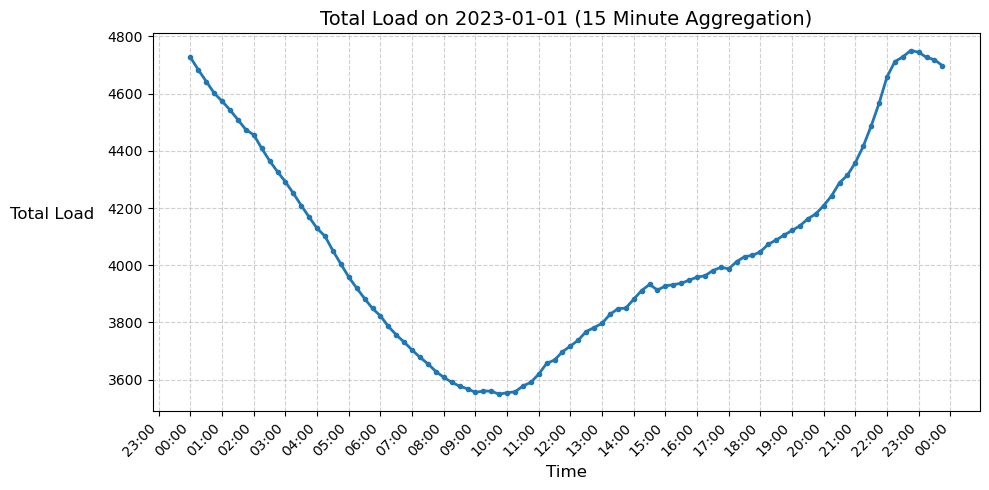

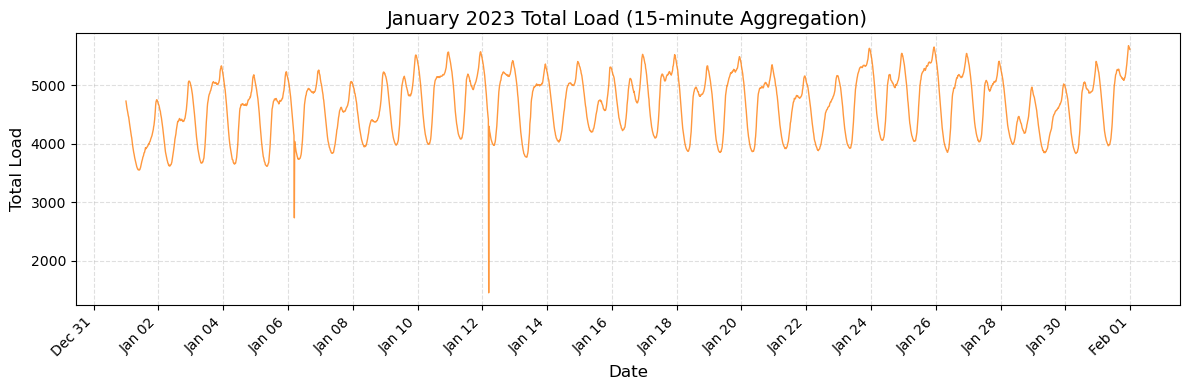

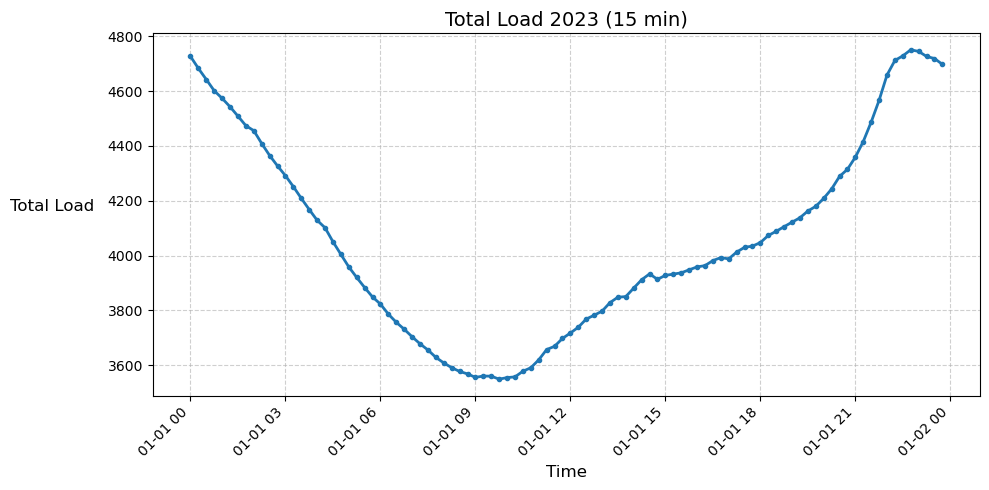

In [3]:
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd


#PLOTS

x = quarter.datetime
y = quarter.total_load


    # TODO: DAILY
# Filter for one day (first day in dataset)
one_day = quarter[quarter['datetime'].dt.date == quarter['datetime'].dt.date.iloc[0]]

# --- PLOT ---
plt.figure(figsize=(10, 5))
plt.plot(one_day['datetime'], one_day['total_load'],
         color='tab:blue', linewidth=2, marker='.', markersize=6)

# --- LABELS AND TITLE ---
plt.title(f'Total Load on {one_day["datetime"].dt.date.iloc[0]} (15 Minute Aggregation)', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))

plt.ylabel('Total Load', fontsize=12, rotation= 360, labelpad = 40)  # proper y-axis rotation

# --- ROTATE X-TICK LABELS ---
plt.xticks(rotation=45, ha='right')  # rotate labels and align right

# --- GRID ---
plt.grid(True, linestyle='--', alpha=0.6)

# Adjust spacing so nothing intersects
plt.tight_layout()

plt.show()

#     # TODO: MONTHLY 


jan = quarter[quarter['datetime'].dt.month == 1].copy()
plt.figure(figsize=(12, 4))
plt.plot(jan['datetime'], jan['total_load'], color='tab:orange', linewidth=1, alpha=0.8)
plt.title('January 2023 Total Load (15-minute Aggregation)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Load', fontsize=12)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

#     # TODO: YEARLY 


plt.figure(figsize=(10, 5))
plt.plot(one_day['datetime'], one_day['total_load'],
         color='tab:blue', linewidth=2, marker='.', markersize=6)

# --- LABELS AND TITLE ---
plt.title('Total Load 2023 (15 min)', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Total Load', fontsize=12, rotation= 360, labelpad = 40)  # proper y-axis rotation
plt.xticks(rotation=45, ha='right')  # rotate labels and align right
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


#### Spline

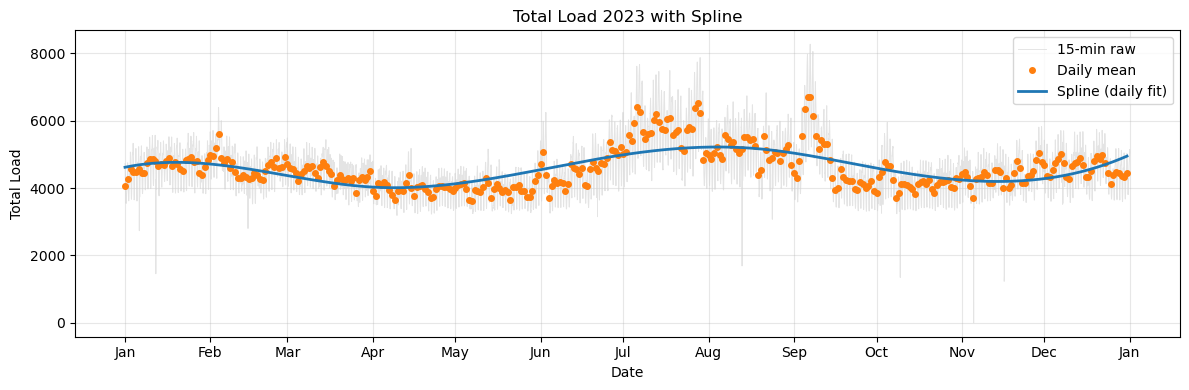

In [4]:
from scipy.interpolate import UnivariateSpline


# Aggregate to daily means for a stable spline fit
daily = quarter.set_index('datetime')['total_load'].resample('D').mean().reset_index()

# Convert dates to numeric values for spline fitting
x_num = mdates.date2num(daily['datetime'])
y_daily = daily['total_load'].values

# Fit a smoothing spline (adjust `s` to change smoothness)
s = len(x_num) * np.var(y_daily) * 0.5
spline = UnivariateSpline(x_num, y_daily, s=s)

# Evaluate spline on a dense grid for a smooth curve
x_dense = np.linspace(x_num.min(), x_num.max(), 1000)
y_smooth = spline(x_dense)
x_dense_dates = mdates.num2date(x_dense)

# Plot original 15-min data (light), daily means (points), and spline (smooth)
plt.figure(figsize=(12, 4))
plt.plot(quarter['datetime'], quarter['total_load'], color='lightgray', linewidth=0.7, alpha=0.6, label='15-min raw')
plt.plot(daily['datetime'], daily['total_load'], 'o', color='tab:orange', markersize=4, label='Daily mean')
plt.plot(x_dense_dates, y_smooth, color='tab:blue', linewidth=2, label='Spline (daily fit)')
plt.title('Total Load 2023 with Spline')
plt.xlabel('Date')
plt.ylabel('Total Load')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()







### Summary Statistics

In [5]:
#TODO: Create Summary Statistics for Hourly, Month, Year 

periods = {'Jan 1': one_day, 'January': jan, 'Year': quarter}
rows = []
for name, df in periods.items():
    if df.empty:
        rows.append({'period': name, 'count': 0})
        continue
    s = df['total_load'].describe()
    peak_idx = df['total_load'].idxmax()
    peak_time = df.loc[peak_idx, 'datetime']
    peak_val = df.loc[peak_idx, 'total_load']
    rows.append({
        'period': name,
        'count': int(s['count']),
        'mean': round(s['mean'], 2),
        'std': round(s['std'], 2),
        'min': round(s['min'], 2),
        '25%': round(s['25%'], 2),
        '50%': round(s['50%'], 2),
        '75%': round(s['75%'], 2),
        'max': round(s['max'], 2),
        'sum': round(df['total_load'].sum(), 2),
        'peak_time': pd.to_datetime(peak_time).strftime('%Y-%m-%d %H:%M:%S'),
        'peak_value': round(peak_val, 2),
    })

summary_stats = pd.DataFrame(rows).set_index('period')
summary_stats


,count,mean,std,min,25%,50%,75%,max,sum,peak_time,peak_value
period,,,,,,,,,,,
Jan 1,96,4058.21,364.20,3548.93,3765.32,3990.17,4317.67,4750.78,3.895881e+05,2023-01-01 22:45:00,4750.78
January,2976,4648.81,505.14,1457.22,4203.27,4726.59,5059.20,5671.44,1.383485e+07,2023-01-31 22:45:00,5671.44
Year,35040,4575.92,784.36,0.00,4037.57,4460.61,4987.11,8270.83,1.603403e+08,2023-09-06 21:45:00,8270.83
